# Sholl Analysis for Phalloidin-based Morphology - FINAL VERSION

## Overview

This notebook performs comprehensive Sholl analysis on phalloidin-labeled neurons across multiple timepoints and treatment conditions.

### Analysis Pipeline:
1. **Load & Map Metadata**: Extract timepoint (HIC) and treatment group from plate positions
2. **Cell Type Classification**: Filter to analyze only live single neurons
3. **Soma Exclusion**: Remove nucleus region from skeleton using DAPI mask + buffer
4. **Skeleton Analysis**: Compute Sholl profiles from nucleus centroid
5. **Batch Processing**: Process all files with progress tracking
6. **Visualization**: Save per-file QC images and overview plots
7. **Export**: Multiple CSV outputs for downstream statistical analysis

### Key Features:
- **Treatment groups**: Control, 50µM DFP, 100µM DFP, 100µM DFO
- **Timepoints**: 24HIC, 48HIC, 72HIC, 96HIC
- **Quality control**: Edge exclusion, size filtering, cell type classification
- **Outputs**: Sholl profiles, summary statistics, skeleton visualizations

In [1]:
# Imports
import pathlib
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyclesperanto_prototype as cle
import seaborn as sns
import seaborn.objects as so
import skan
from bioio import BioImage
from napari_ndev import PlateMapper
from scipy.ndimage import binary_dilation
from skan import draw
from skimage import measure
from skimage.morphology import skeletonize
from tqdm.auto import tqdm

# For better progress bars
tqdm.pandas()

# for saving plots with svg, this saves text as text instead of ['paths']
sns.set_theme()
plt.rcParams['svg.fonttype'] = 'none'

# FULL BATCH PROCESSING - ALL FILES
# Set to False for testing on subset, True for full run
FULL_RUN = True

# HIC TIMEPOINT FILTERING
# List of HIC timepoints to exclude from analysis
# Set to empty list [] to include all timepoints
EXCLUDE_HIC = ['18HIC', '96HIC']

# CONSTANTS (in real units, µm)
MINIMUM_SEGMENT_LENGTH = 4  # µm, filter out tiny branches
SKELETON_MERGE_DISTANCE = 0.01  # µm, for connecting broken endpoints (conservative for actin)
SOMA_EXCLUSION_BUFFER = 3  # µm, dilate the nucleus mask by this amount to exclude soma

# Sholl analysis parameters
SHOLL_INNER_RING = 5  # µm
SHOLL_OUTER_RING = 300  # µm, adjust based on cell size
SHOLL_RING_SPACING = 1  # µm

In [2]:
# File management
working_dir = pathlib.Path('.')
label_dir = working_dir / 'Processed_Labels_3umconnect'  # _BINA is just 48HIC but otherwise labels look identical
output_dir = working_dir / 'Sholl_Analysis_Output'
output_dir.mkdir(exist_ok=True)

# Create subdirectories for organized outputs
qc_dir = output_dir / 'QC_Images'
qc_dir.mkdir(exist_ok=True)

skeleton_dir = output_dir / 'Skeleton_Overlays'
skeleton_dir.mkdir(exist_ok=True)

label_files = sorted(list(label_dir.glob('*.ome.tiff')))

print(f"Found {len(label_files)} label files")
print("\nOutput directories:")
print(f"  Main: {output_dir}")
print(f"  QC Images: {qc_dir}")
print(f"  Skeleton Overlays: {skeleton_dir}")
print("\nFirst 5 files:")
for idx, file in enumerate(label_files[:5]):
    print(f"  {idx}: {file.name}")

Found 551 label files

Output directories:
  Main: Sholl_Analysis_Output
  QC Images: Sholl_Analysis_Output\QC_Images
  Skeleton Overlays: Sholl_Analysis_Output\Skeleton_Overlays

First 5 files:
  0: 2024-08-07 25x 18HIC VERSION 1 NCOA4 647 FT 568 PHALL 488 DAPI OBL_0_0_P1-A9.ome.tiff
  1: 2024-08-07 25x 18HIC VERSION 1 NCOA4 647 FT 568 PHALL 488 DAPI OBL_100_99_P12-G9.ome.tiff
  2: 2024-08-07 25x 18HIC VERSION 1 NCOA4 647 FT 568 PHALL 488 DAPI OBL_101_100_P2-H9.ome.tiff
  3: 2024-08-07 25x 18HIC VERSION 1 NCOA4 647 FT 568 PHALL 488 DAPI OBL_102_101_P4-H9.ome.tiff
  4: 2024-08-07 25x 18HIC VERSION 1 NCOA4 647 FT 568 PHALL 488 DAPI OBL_103_102_P3-H9.ome.tiff


## Metadata Extraction & Plate Mapping

Extract experimental metadata from filenames and map plate positions to treatment groups.

In [3]:
# Setup plate mapper for treatment assignments
treatments = {
    'chelation': {
        'Control': ['B1:C12'],
        '50uM DFP': ['D1:E12'],
        '100uM DFP': ['F1:G12'],
        '100uM DFO': ['A1:A12', 'H1:H12'],
    },
}

plate = PlateMapper(96)
plate.assign_treatments(treatments)
plate_df = plate.plate_map

# Display plate map
print("Treatment Plate Map:")
display(plate.get_styled_plate_map('chelation'))

print(f"\nPlate map shape: {plate_df.shape}")
plate_df.head()

Treatment Plate Map:


c:\Users\timmo\Documents\GitHub\BastianLab\Ferritin_NCOA4-Phalloidin\.venv\Lib\site-packages\napari_ndev\_plate_mapper.py:210: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  self.pivoted_plate_map.style.applymap(get_background_color)


column,1,2,3,4,5,6,7,8,9,10,11,12
row,,,,,,,,,,,,
A,100uM DFO,100uM DFO,100uM DFO,100uM DFO,100uM DFO,100uM DFO,100uM DFO,100uM DFO,100uM DFO,100uM DFO,100uM DFO,100uM DFO
B,Control,Control,Control,Control,Control,Control,Control,Control,Control,Control,Control,Control
C,Control,Control,Control,Control,Control,Control,Control,Control,Control,Control,Control,Control
D,50uM DFP,50uM DFP,50uM DFP,50uM DFP,50uM DFP,50uM DFP,50uM DFP,50uM DFP,50uM DFP,50uM DFP,50uM DFP,50uM DFP
E,50uM DFP,50uM DFP,50uM DFP,50uM DFP,50uM DFP,50uM DFP,50uM DFP,50uM DFP,50uM DFP,50uM DFP,50uM DFP,50uM DFP
F,100uM DFP,100uM DFP,100uM DFP,100uM DFP,100uM DFP,100uM DFP,100uM DFP,100uM DFP,100uM DFP,100uM DFP,100uM DFP,100uM DFP
G,100uM DFP,100uM DFP,100uM DFP,100uM DFP,100uM DFP,100uM DFP,100uM DFP,100uM DFP,100uM DFP,100uM DFP,100uM DFP,100uM DFP
H,100uM DFO,100uM DFO,100uM DFO,100uM DFO,100uM DFO,100uM DFO,100uM DFO,100uM DFO,100uM DFO,100uM DFO,100uM DFO,100uM DFO



Plate map shape: (96, 4)


,row,column,well_id,chelation
0,A,1,A1,100uM DFO
1,A,2,A2,100uM DFO
2,A,3,A3,100uM DFO
3,A,4,A4,100uM DFO
4,A,5,A5,100uM DFO


In [4]:
# Function to extract metadata from filenames
def extract_file_metadata(filename):
    """
    Extract HIC timepoint and plate well position from filename.
    
    Example filename: 2024-08-07 25x 72HIC NCOA4 647 FT 568 PHALL 488 DAPI OBL_0_0_P1-A9.ome.tiff
    Where P1-A9 means Position 1, Well A9
    Returns: {'HIC': '72', 'well': 'A9', 'position': 'P1'}
    """
    # Extract HIC (timepoint)
    hic_match = re.search(r'(\d{1,3})HIC', filename)
    hic = hic_match.group(1) if hic_match else None

    # Extract well position (e.g., P1-A9 → position=P1, well=A9)
    well_match = re.search(r'(P\d+)-([A-H]\d{1,2})', filename)
    if well_match:
        position = well_match.group(1)  # e.g., P1, P12, P14
        well = well_match.group(2)       # e.g., A9, G9, H9
    else:
        position = None
        well = None

    return {
        'HIC': hic,
        'well': well,
        'position': position,
        'filename': filename
    }

# Test on first few files
print("Testing metadata extraction:")
for file in label_files[:5]:
    metadata = extract_file_metadata(file.name)
    print(f"  {file.name}")
    print(f"    → HIC: {metadata['HIC']}, Well: {metadata['well']}, Position: {metadata['position']}\n")

Testing metadata extraction:
  2024-08-07 25x 18HIC VERSION 1 NCOA4 647 FT 568 PHALL 488 DAPI OBL_0_0_P1-A9.ome.tiff
    → HIC: 18, Well: A9, Position: P1

  2024-08-07 25x 18HIC VERSION 1 NCOA4 647 FT 568 PHALL 488 DAPI OBL_100_99_P12-G9.ome.tiff
    → HIC: 18, Well: G9, Position: P12

  2024-08-07 25x 18HIC VERSION 1 NCOA4 647 FT 568 PHALL 488 DAPI OBL_101_100_P2-H9.ome.tiff
    → HIC: 18, Well: H9, Position: P2

  2024-08-07 25x 18HIC VERSION 1 NCOA4 647 FT 568 PHALL 488 DAPI OBL_102_101_P4-H9.ome.tiff
    → HIC: 18, Well: H9, Position: P4

  2024-08-07 25x 18HIC VERSION 1 NCOA4 647 FT 568 PHALL 488 DAPI OBL_103_102_P3-H9.ome.tiff
    → HIC: 18, Well: H9, Position: P3



In [5]:
# Load a test file and examine structure
test_file = label_files[1]
img = BioImage(test_file)

# Extract metadata
test_metadata = extract_file_metadata(test_file.name)

# Get treatment from plate map (using well position)
if test_metadata['well'] and test_metadata['well'] in plate_df['well_id'].values:
    test_treatment = plate_df[plate_df['well_id'] == test_metadata['well']]['chelation'].values[0]
else:
    test_treatment = 'Unknown'

print(f"Test file: {test_file.name}")
print(f"  HIC: {test_metadata['HIC']}")
print(f"  Position: {test_metadata['position']}")
print(f"  Well: {test_metadata['well']}")
print(f"  Treatment: {test_treatment}")
print("\nImage properties:")
print(f"  Channel names: {img.channel_names}")
print(f"  Pixel size (X): {img.physical_pixel_sizes.X} µm")
print(f"  Image shape: {img.shape}")
print(f"  Dims: {img.dims}")

pixelsize = img.physical_pixel_sizes.X


Test file: 2024-08-07 25x 18HIC VERSION 1 NCOA4 647 FT 568 PHALL 488 DAPI OBL_100_99_P12-G9.ome.tiff
  HIC: 18
  Position: P12
  Well: G9
  Treatment: 100uM DFP

Image properties:
  Channel names: ['DAPI', 'Ferritin', 'NCOA4', 'Morphology', 'DAPI Class']
  Pixel size (X): 0.12408040410185801 µm
  Image shape: (1, 5, 1, 2508, 2500)
  Dims: <Dimensions [T: 1, C: 5, Z: 1, Y: 2508, X: 2500]>


In [6]:
# Extract labels from test file
dapi_labels = img.get_image_data("YX", C=0)
morphology_labels = img.get_image_data("YX", C=3)
dapi_class = img.get_image_data("YX", C=4)

print(f"DAPI labels: {dapi_labels.max()} nuclei")
print(f"Morphology labels: {morphology_labels.max()} cells")
print(f"DAPI classes: unique values = {np.unique(dapi_class)}")

DAPI labels: 3 nuclei
Morphology labels: 39 cells
DAPI classes: unique values = [0 1]


In [7]:
# # Visualize labels
# viewer = napari.Viewer()
# viewer.add_labels(dapi_labels, name='DAPI')
# viewer.add_labels(morphology_labels, name='Morphology')
# viewer.add_labels(dapi_class, name='DAPI Class')

## Constants and Parameters

Key parameters for Sholl analysis with phalloidin:

## Cell Type Classification

Filter morphology labels to only analyze live single neurons based on DAPI class information.

In [8]:
def determine_cell_type(dapi_labels, dapi_class, morphology_labels, morphology_label_id):
    """
    Determine the cell type for a morphology label based on DAPI class.
    
    Returns:
        'live cell': Single live neuron (DAPI class = 1, single nucleus)
        'dead cell': Dead neuron (DAPI class = 2)
        'debris': Debris (DAPI class = 3)
        'fragment': No nucleus (INTEGRATED_INTENSITY = 0)
        'cluster': Multiple nuclei or mixed classes
        None: Other cases
    """
    # Create binary mask for this morphology label
    morph_mask = morphology_labels == morphology_label_id

    # Find overlapping DAPI class values
    dapi_in_morph = dapi_class * morph_mask

    # Get unique DAPI class values (excluding background 0)
    unique_classes = np.unique(dapi_in_morph[dapi_in_morph > 0])

    # Get counts of each DAPI label
    dapi_in_morph_labels = dapi_labels * morph_mask
    num_nuclei = len(np.unique(dapi_in_morph_labels[dapi_in_morph_labels > 0]))

    # Classify
    if len(unique_classes) == 0:
        return 'fragment'
    elif len(unique_classes) == 1 and num_nuclei == 1:
        if unique_classes[0] == 1:
            return 'live cell'
        elif unique_classes[0] == 2:
            return 'dead cell'
        elif unique_classes[0] == 3:
            return 'debris'
    elif num_nuclei > 1 or len(unique_classes) > 1:
        return 'cluster'

    return None


def classify_all_cells(dapi_labels, dapi_class, morphology_labels):
    """
    Classify all morphology labels in an image.
    
    Returns a dictionary mapping morphology_label_id to cell_type.
    """
    cell_types = {}
    morph_ids = np.unique(morphology_labels)
    morph_ids = morph_ids[morph_ids > 0]

    for morph_id in morph_ids:
        cell_type = determine_cell_type(dapi_labels, dapi_class, morphology_labels, morph_id)
        cell_types[morph_id] = cell_type

    return cell_types

In [9]:
# Test cell type classification on the current image
cell_types = classify_all_cells(dapi_labels, dapi_class, morphology_labels)

# Convert to DataFrame for easy viewing
cell_type_df = pd.DataFrame(list(cell_types.items()), columns=['morphology_id', 'cell_type'])
print(cell_type_df['cell_type'].value_counts())
print(f"\nTotal morphology labels: {len(cell_type_df)}")
print(f"Live cells: {(cell_type_df['cell_type'] == 'live cell').sum()}")

cell_type_df

cell_type
fragment     37
live cell     1
cluster       1
Name: count, dtype: int64

Total morphology labels: 39
Live cells: 1


,morphology_id,cell_type
0,1,fragment
1,2,fragment
2,3,fragment
3,4,fragment
4,5,fragment
5,6,fragment
6,7,fragment
7,8,fragment
8,9,fragment
9,10,fragment


## Label Filtering & Quality Control

Apply pre-filtering to morphology labels:
1. **Edge exclusion**: Remove cells touching image borders (incomplete neurons)
2. **Size filtering**: Remove fragments (too small) and clusters (too large)
3. **Cell type classification**: Further filter to only "live cell" type

In [10]:
def filter_labels_by_quality(morphology_labels, min_area_um2=None, max_area_um2=None):
    """
    Filter morphology labels by size and edge exclusion.
    
    Args:
        morphology_labels: Label image
        min_area_um2: Minimum area in µm² (None to skip)
        max_area_um2: Maximum area in µm² (None to skip)
    
    Returns:
        Filtered label image
    """
    # Exclude labels touching edges
    labels_no_edges = cle.exclude_labels_on_edges(morphology_labels)

    # Size filtering if thresholds provided
    if min_area_um2 is not None or max_area_um2 is not None:
        min_area_px = (min_area_um2 / (pixelsize ** 2)) if min_area_um2 else 0
        max_area_px = (max_area_um2 / (pixelsize ** 2)) if max_area_um2 else np.inf

        labels_filtered = cle.exclude_labels_out_of_size_range(
            labels_no_edges,
            minimum_size=min_area_px,
            maximum_size=max_area_px
        )
    else:
        labels_filtered = labels_no_edges

    return labels_filtered


# Test filtering on current image
MIN_MORPH_AREA = 30  # µm² - minimum neuron area
MAX_MORPH_AREA = 100000  # µm² - maximum neuron area (to exclude large clusters)

morphology_filtered = filter_labels_by_quality(
    morphology_labels,
    min_area_um2=MIN_MORPH_AREA,
    max_area_um2=MAX_MORPH_AREA
)

print(f"Before filtering: {morphology_labels.max()} morphology labels")
print(f"After edge + size filtering: {cle.pull(morphology_filtered).max()} morphology labels")

# Now classify the filtered labels
cell_types_filtered = classify_all_cells(dapi_labels, dapi_class, cle.pull(morphology_filtered))
cell_type_df_filtered = pd.DataFrame(
    list(cell_types_filtered.items()),
    columns=['morphology_id', 'cell_type']
)

print("\nCell types after filtering:")
print(cell_type_df_filtered['cell_type'].value_counts())
print(f"\nLive cells: {(cell_type_df_filtered['cell_type'] == 'live cell').sum()}")

Before filtering: 39 morphology labels
After edge + size filtering: 2 morphology labels

Cell types after filtering:
cell_type
live cell    1
cluster      1
Name: count, dtype: int64

Live cells: 1


In [11]:
# Convert to pixels
minimum_segment_length_px = MINIMUM_SEGMENT_LENGTH / pixelsize
skeleton_merge_distance_px = SKELETON_MERGE_DISTANCE / pixelsize
soma_exclusion_buffer_px = SOMA_EXCLUSION_BUFFER / pixelsize

print(f"Minimum segment length: {minimum_segment_length_px:.1f} px")
print(f"Skeleton merge distance: {skeleton_merge_distance_px:.1f} px")
print(f"Soma exclusion buffer: {soma_exclusion_buffer_px:.1f} px")

Minimum segment length: 32.2 px
Skeleton merge distance: 0.1 px
Soma exclusion buffer: 24.2 px


## Helper Functions

In [12]:
def get_nucleus_centroid(dapi_labels, morphology_labels, morphology_label_id):
    """
    Find the centroid of the nucleus associated with a morphology label.
    
    Strategy: Use the nucleus that overlaps most with the morphology label.
    
    Returns:
        tuple: (centroid_array, nucleus_id) or (None, None) if not found
    """
    # Create binary mask for this morphology label
    morph_mask = morphology_labels == morphology_label_id

    # Find overlapping DAPI labels
    overlapping_dapi = cle.binary_and(morph_mask, dapi_labels > 0)
    dapi_in_morph = dapi_labels * cle.pull(overlapping_dapi)

    if dapi_in_morph.max() == 0:
        return None, None

    # Get the most common DAPI label (highest pixel count)
    unique_labels, counts = np.unique(dapi_in_morph[dapi_in_morph > 0], return_counts=True)
    primary_nucleus_id = unique_labels[np.argmax(counts)]

    # Get centroid of this nucleus
    nucleus_mask = dapi_labels == primary_nucleus_id
    props = measure.regionprops(nucleus_mask.astype(int))

    if len(props) == 0:
        return None, None

    y0, x0 = props[0].centroid
    return np.array([y0, x0]), primary_nucleus_id


def merge_skeleton_endpoints(skeleton, merge_distance_px):
    """
    Iteratively merge nearby skeleton endpoints to connect broken branches.
    Less aggressive than microtubule version for actin structures.
    
    Note: skeleton should be a numpy array (boolean or uint8).
    """
    # Ensure skeleton is numpy array
    if not isinstance(skeleton, np.ndarray):
        skeleton = cle.pull(skeleton)

    skeleton = skeleton.astype(bool)

    degree_img = skan.csr.make_degree_image(skeleton)
    endpoints = degree_img == 1
    num_orig_endpoints = np.count_nonzero(endpoints)

    if num_orig_endpoints == 0:
        return skeleton

    # Single iteration of endpoint merging (conservative approach for actin)
    dilated_endpoints = cle.dilate_labels(
        endpoints, radius=merge_distance_px/2
    )
    endpoints_skeleton = skeletonize(cle.pull(dilated_endpoints))
    combined_skeleton = skeletonize(skeleton + endpoints_skeleton)

    return combined_skeleton


def exclude_soma_from_skeleton(skeleton, dapi_labels, nucleus_id, exclusion_buffer_px):
    """
    Remove skeleton pixels that overlap with the nucleus (soma) plus a buffer.
    
    This approach is more accurate than a circular exclusion since nuclei aren't 
    perfectly circular.
    
    Args:
        skeleton: 2D boolean array
        dapi_labels: DAPI label image
        nucleus_id: ID of the nucleus to use for exclusion
        exclusion_buffer_px: distance to dilate nucleus mask (in pixels)
    
    Returns:
        skeleton with soma excluded (boolean array)
    """
    # Ensure skeleton is numpy array
    if not isinstance(skeleton, np.ndarray):
        skeleton = cle.pull(skeleton)

    skeleton = skeleton.astype(bool)

    # Get the nucleus mask
    nucleus_mask = dapi_labels == nucleus_id

    # Dilate the nucleus mask to create soma exclusion zone
    from scipy.ndimage import binary_dilation
    soma_mask = binary_dilation(
        cle.pull(nucleus_mask),
        iterations=int(np.ceil(exclusion_buffer_px))
    )

    # Exclude soma from skeleton
    skeleton_no_soma = skeleton & ~soma_mask

    return skeleton_no_soma


def skeletonize_morphology(morph_label, min_segment_length_px):
    """
    Skeletonize a morphology label and filter small segments.
    
    Returns a numpy boolean array.
    """
    # Skeletonize
    skeleton = skeletonize(cle.pull(morph_label > 0))

    # Label connected components
    skeleton_labeled = cle.label(skeleton)

    # Filter by length
    skeleton_filtered = cle.exclude_small_labels(
        skeleton_labeled, None, min_segment_length_px
    )

    # Return as numpy array (boolean)
    return cle.pull(skeleton_filtered > 0).astype(bool)

## Test Sholl Analysis on Single Cell

In [13]:
# Test on first LIVE CELL morphology label
# Classify all cells first
cell_types = classify_all_cells(dapi_labels, dapi_class, morphology_labels)
live_cell_ids = [k for k, v in cell_types.items() if v == 'live cell']

print(f"Found {len(live_cell_ids)} live cells in this image")

if len(live_cell_ids) > 0:
    test_morph_id = live_cell_ids[0]
    print(f"Testing on morphology label {test_morph_id}")

    # Get nucleus centroid and ID
    centroid, nucleus_id = get_nucleus_centroid(dapi_labels, morphology_labels, test_morph_id)
    print(f"Nucleus centroid (pixels): {centroid}")
    print(f"Nucleus ID: {nucleus_id}")

    if centroid is not None:
        # Extract and skeletonize morphology
        morph_mask = morphology_labels == test_morph_id
        skeleton = skeletonize_morphology(morph_mask, minimum_segment_length_px)

        # Exclude soma region using actual nucleus mask
        skeleton_no_soma = exclude_soma_from_skeleton(
            skeleton, dapi_labels, nucleus_id, soma_exclusion_buffer_px
        )

        # Optional: merge endpoints
        skeleton_merged = merge_skeleton_endpoints(skeleton_no_soma, skeleton_merge_distance_px)

        print(f"Skeleton pixels: {np.count_nonzero(skeleton)}")
        print(f"Skeleton (no soma) pixels: {np.count_nonzero(skeleton_no_soma)}")
        print(f"Merged skeleton pixels: {np.count_nonzero(skeleton_merged)}")

        # Get soma mask for visualization
        from scipy.ndimage import binary_dilation
        nucleus_mask = dapi_labels == nucleus_id
        soma_mask = binary_dilation(
            cle.pull(nucleus_mask),
            iterations=int(np.ceil(soma_exclusion_buffer_px))
        )

        # Visualize
        # viewer = napari.Viewer()
        # viewer.add_labels(morph_mask.astype(int), name='Morphology')
        # viewer.add_labels(nucleus_mask.astype(int), name='Nucleus', opacity=0.5)
        # viewer.add_labels(soma_mask.astype(int), name='Soma Exclusion Zone', opacity=0.3)
        # viewer.add_labels(skeleton.astype(int), name='Skeleton')
        # viewer.add_labels(skeleton_no_soma.astype(int), name='Skeleton (No Soma)')
        # viewer.add_labels(skeleton_merged.astype(int), name='Skeleton Merged')
        # viewer.add_points([centroid], size=10, face_color='red', name='Centroid')
else:
    print("No live cells found in this image!")

Found 1 live cells in this image
Testing on morphology label 31
Nucleus centroid (pixels): [ 263.84658884 1391.64447282]
Nucleus ID: 1
Skeleton pixels: 1282
Skeleton (no soma) pixels: 817
Merged skeleton pixels: 822
Skeleton pixels: 1282
Skeleton (no soma) pixels: 817
Merged skeleton pixels: 822


Sholl analysis complete
Max crossings: 10 at radius 18 µm


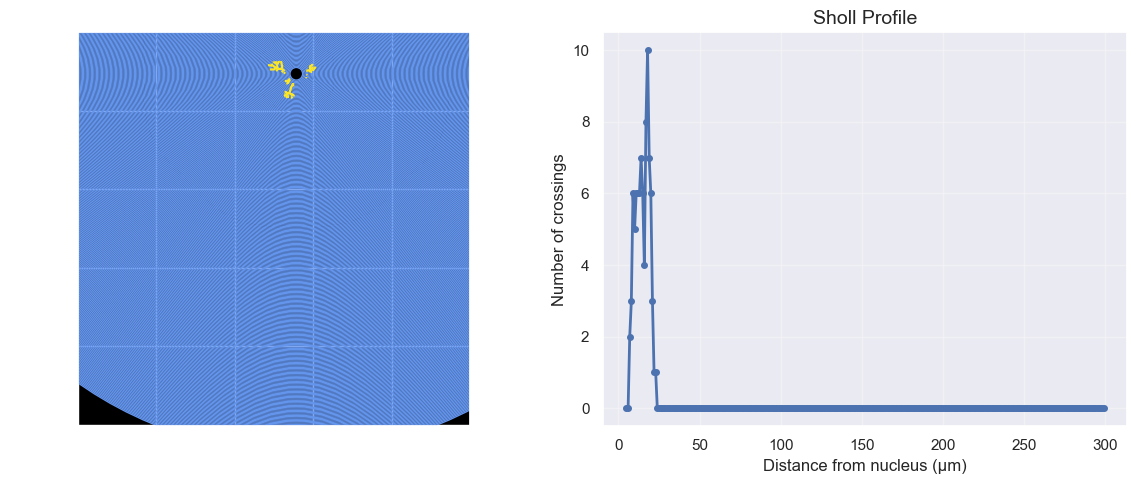

In [14]:
# Perform Sholl analysis
if centroid is not None:
    try:
        # Create skan skeleton object
        csr_skeleton = skan.csr.Skeleton(
            skeleton_image=skeleton_merged.astype(float),
            spacing=pixelsize
        )

        # Define shells
        center_um = centroid * pixelsize
        radii = np.arange(SHOLL_INNER_RING, SHOLL_OUTER_RING, SHOLL_RING_SPACING)

        # Perform Sholl analysis
        center_result, radii_result, counts = skan.sholl_analysis(
            csr_skeleton, center=center_um, shells=radii
        )

        print("Sholl analysis complete")
        print(f"Max crossings: {counts.max()} at radius {radii[np.argmax(counts)]} µm")

        # Plot results
        fig, (ax0, ax1) = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))

        # Draw skeleton with shells
        draw.overlay_skeleton_2d_class(
            skeleton=csr_skeleton,
            image_cmap='gray',
            skeleton_colormap='viridis_r',
            vmin=0,
            axes=ax0
        )
        # Draw the shells in pixel coordinates
        draw.sholl_shells(center_um / pixelsize, radii / pixelsize, axes=ax0)

        # Fiddle with plot visual aspects
        ax0.set_xlim([0, skeleton_merged.shape[1]])
        ax0.set_ylim([skeleton_merged.shape[0], 0])  # Inverted for image coordinates
        ax0.set_facecolor('black')
        ax0.set_aspect('equal')
        ax0.set_title('Skeleton with Sholl Shells', color='white')
        ax0.set_xlabel('X (pixels)', color='white')
        ax0.set_ylabel('Y (pixels)', color='white')
        ax0.tick_params(colors='white')

        # Plot Sholl profile
        ax1.plot(radii, counts, 'o-', linewidth=2, markersize=4)
        ax1.set_xlabel('Distance from nucleus (µm)', fontsize=12)
        ax1.set_ylabel('Number of crossings', fontsize=12)
        ax1.set_title('Sholl Profile', fontsize=14)
        ax1.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"Error during Sholl analysis: {e}")

## Batch Processing

Apply Sholl analysis to all files and morphology labels

### Quality Control Notes

The batch processing now includes automatic filtering to only analyze **live single neurons**:

**Cell Type Classification:**
- ✅ **live cell**: Single nucleus with DAPI class = 1
- ❌ **dead cell**: Single nucleus with DAPI class = 2  
- ❌ **debris**: DAPI class = 3
- ❌ **fragment**: No nucleus detected
- ❌ **cluster**: Multiple nuclei or mixed DAPI classes

Only "live cell" morphologies are included in the Sholl analysis to ensure clean data.

In [15]:
def save_file_visualization(filename, skeleton_data, dapi_labels, morphology_labels,
                           cell_counts, hic, treatment):
    """
    Save comprehensive QC visualization for a file showing:
    - Example skeletons with Sholl shells
    - Cell type distribution
    - Soma exclusion zones
    """
    n_examples = len(skeleton_data)
    fig, axes = plt.subplots(1, n_examples, figsize=(5*n_examples, 5))

    if n_examples == 1:
        axes = [axes]

    for idx, data in enumerate(skeleton_data):
        ax = axes[idx]

        # Create Sholl skeleton
        csr_skeleton = skan.csr.Skeleton(
            skeleton_image=data['skeleton'].astype(float),
            spacing=pixelsize
        )

        # Draw skeleton with shells
        center_um = data['centroid'] * pixelsize
        radii = np.arange(SHOLL_INNER_RING, SHOLL_OUTER_RING, SHOLL_RING_SPACING)

        draw.overlay_skeleton_2d_class(
            skeleton=csr_skeleton,
            image_cmap='gray',
            skeleton_colormap='viridis_r',
            vmin=0,
            axes=ax
        )
        draw.sholl_shells(center_um / pixelsize, radii / pixelsize, axes=ax)

        # Visual styling
        ax.set_xlim([0, data['skeleton'].shape[1]])
        ax.set_ylim([data['skeleton'].shape[0], 0])
        ax.set_facecolor('black')
        ax.set_aspect('equal')
        ax.set_title(f'Cell {data["morph_id"]}', color='white', fontsize=10)
        ax.tick_params(colors='white', labelsize=8)

    # Overall title
    cell_type_str = ', '.join([f"{k}: {v}" for k, v in cell_counts.items()])
    fig.suptitle(
        f'{filename}\n{hic}HIC | {treatment} | {cell_type_str}',
        color='white', fontsize=12, y=0.98
    )
    fig.patch.set_facecolor('black')

    plt.tight_layout()
    plt.savefig(
        skeleton_dir / f'{filename}_skeletons.png',
        dpi=150,
        facecolor='black',
        bbox_inches='tight'
    )
    plt.close()

In [16]:
# Enhanced batch processing function with metadata and visualization
def process_file_with_metadata(
    file_path, pixelsize, minimum_segment_length_px, skeleton_merge_distance_px,
    soma_exclusion_buffer_px, plate_df, min_area_um2, max_area_um2,
    save_visualizations=True
):
    """
    Process a single label file with complete metadata tracking and optional visualizations.
    
    Returns:
        tuple: (sholl_results, cell_summary, error_log)
    """
    # Extract metadata
    metadata = extract_file_metadata(file_path.name)
    hic = metadata['HIC']
    well = metadata['well']

    # Get treatment from plate map
    if well and well in plate_df['well_id'].values:
        treatment = plate_df[plate_df['well_id'] == well]['chelation'].values[0]
    else:
        treatment = 'Unknown'

    # Load image
    try:
        img = BioImage(file_path)
        dapi_labels = img.get_image_data("YX", C=0)
        morphology_labels = img.get_image_data("YX", C=3)
        dapi_class = img.get_image_data("YX", C=4)
    except Exception as e:
        return [], [], [{'file': file_path.stem, 'error': f'Image loading failed: {e}'}]

    # Pre-filter morphology labels
    morphology_filtered = filter_labels_by_quality(
        morphology_labels,
        min_area_um2=min_area_um2,
        max_area_um2=max_area_um2
    )
    morphology_filtered = cle.pull(morphology_filtered)

    # Classify all cells
    cell_types = classify_all_cells(dapi_labels, dapi_class, morphology_filtered)

    # Get only live cell IDs
    live_cell_ids = [k for k, v in cell_types.items() if v == 'live cell']

    # Count all cell types for summary
    cell_type_counts = {}
    for cell_type in set(cell_types.values()):
        cell_type_counts[cell_type] = sum(1 for v in cell_types.values() if v == cell_type)

    print(f"  Total cells: {len(cell_types)}, Live cells: {len(live_cell_ids)}")

    sholl_results = []
    cell_summary = []
    error_log = []
    skeleton_images = []  # For visualization

    for morph_id in live_cell_ids:
        # Get nucleus centroid and ID
        centroid, nucleus_id = get_nucleus_centroid(dapi_labels, morphology_filtered, morph_id)
        if centroid is None:
            continue

        # Skeletonize
        morph_mask = morphology_filtered == morph_id
        skeleton = skeletonize_morphology(morph_mask, minimum_segment_length_px)

        if skeleton.sum() == 0:
            continue

        # Exclude soma using nucleus mask + buffer
        skeleton_no_soma = exclude_soma_from_skeleton(
            skeleton, dapi_labels, nucleus_id, soma_exclusion_buffer_px
        )

        if skeleton_no_soma.sum() == 0:
            continue

        # Optional endpoint merging
        skeleton_merged = merge_skeleton_endpoints(skeleton_no_soma, skeleton_merge_distance_px)

        # Store for visualization
        if save_visualizations and len(skeleton_images) < 3:  # Save first 3 cells per file
            skeleton_images.append({
                'morph_id': morph_id,
                'centroid': centroid,
                'nucleus_id': nucleus_id,
                'skeleton': skeleton_merged,
                'morph_mask': morph_mask
            })

        try:
            # Skan analysis
            csr_skeleton = skan.csr.Skeleton(
                skeleton_image=skeleton_merged.astype(float),
                spacing=pixelsize
            )

            # Sholl analysis
            center_um = centroid * pixelsize
            radii = np.arange(SHOLL_INNER_RING, SHOLL_OUTER_RING, SHOLL_RING_SPACING)
            center_result, radii_result, counts = skan.sholl_analysis(
                csr_skeleton, center=center_um, shells=radii
            )

            # Store Sholl results
            for radius, count in zip(radii_result, counts):
                sholl_results.append({
                    'file': file_path.stem,
                    'HIC': hic,
                    'well': well,
                    'treatment': treatment,
                    'morphology_id': morph_id,
                    'radius_um': radius,
                    'crossings': count,
                    'centroid_y': centroid[0],
                    'centroid_x': centroid[1],
                    'cell_type': 'live cell'
                })

            # Store per-cell summary
            cell_summary.append({
                'file': file_path.stem,
                'HIC': hic,
                'well': well,
                'treatment': treatment,
                'morphology_id': morph_id,
                'max_crossings': counts.max(),
                'radius_at_max': radii[np.argmax(counts)],
                'total_crossings': counts.sum(),
                'skeleton_pixels': skeleton_merged.sum(),
                'cell_type': 'live cell'
            })

        except Exception as e:
            error_log.append({
                'file': file_path.stem,
                'morphology_id': morph_id,
                'error': str(e)
            })
            continue

    # Create visualization if requested
    if save_visualizations and skeleton_images:
        try:
            save_file_visualization(
                file_path.stem, skeleton_images, dapi_labels,
                morphology_filtered, cell_type_counts, hic, treatment
            )
        except Exception as e:
            print(f"    Warning: Visualization failed: {e}")

    return sholl_results, cell_summary, error_log


In [17]:

SAVE_VISUALIZATIONS = True

# Filter files based on EXCLUDE_HIC list
if EXCLUDE_HIC:
    filtered_files = [f for f in label_files if not any(hic in f.name for hic in EXCLUDE_HIC)]
    skipped_count = len(label_files) - len(filtered_files)
    print(f"🚫 Excluding timepoints: {', '.join(EXCLUDE_HIC)}")
    print(f"   Skipped {skipped_count} files")
else:
    filtered_files = label_files
    print("✓ Processing all timepoints (no exclusions)")

# Select files to process
if FULL_RUN:
    files_to_process = filtered_files
    print(f"🚀 FULL RUN: Processing {len(files_to_process)} files")
else:
    files_to_process = filtered_files[:5]
    print(f"🧪 TEST RUN: Processing {len(files_to_process)} files (from {len(filtered_files)} available)")


# Initialize result collectors
all_sholl_results = []
all_cell_summaries = []
all_errors = []

# Process with progress bar
for file in tqdm(files_to_process, desc="Processing files"):
    print(f"\n📁 {file.name}")

    sholl_results, cell_summary, errors = process_file_with_metadata(
        file,
        pixelsize,
        minimum_segment_length_px,
        skeleton_merge_distance_px,
        soma_exclusion_buffer_px,
        plate_df,
        MIN_MORPH_AREA,
        MAX_MORPH_AREA,
        save_visualizations=SAVE_VISUALIZATIONS
    )

    all_sholl_results.extend(sholl_results)
    all_cell_summaries.extend(cell_summary)
    all_errors.extend(errors)

    print(f"  ✓ {len(sholl_results)} Sholl measurements, {len(cell_summary)} cells analyzed")

    # Save intermediate results every 10 files
    if (len(all_sholl_results) > 0) and (len(all_sholl_results) % 10 == 0):
        pd.DataFrame(all_sholl_results).to_csv(
            output_dir / 'sholl_profiles_TEMP.csv',
            index=False
        )
        print("  💾 Intermediate save complete")

print(f"\n{'='*60}")
print("✨ BATCH PROCESSING COMPLETE")
print(f"{'='*60}")
print(f"Total Sholl measurements: {len(all_sholl_results)}")
print(f"Total cells analyzed: {len(all_cell_summaries)}")
print(f"Total errors: {len(all_errors)}")

🚫 Excluding timepoints: 18HIC, 96HIC
   Skipped 193 files
🚀 FULL RUN: Processing 358 files


Processing files:   0%|          | 0/358 [00:00<?, ?it/s]


📁 2024-08-07 25x 24HIC NCOA4 647 FT 568 PHALL 488 DAPI OBL_0_0_P2-A9.ome.tiff
  Total cells: 3, Live cells: 2
  Total cells: 3, Live cells: 2
  ✓ 590 Sholl measurements, 2 cells analyzed
  💾 Intermediate save complete

📁 2024-08-07 25x 24HIC NCOA4 647 FT 568 PHALL 488 DAPI OBL_100_99_P9-G9.ome.tiff
  ✓ 590 Sholl measurements, 2 cells analyzed
  💾 Intermediate save complete

📁 2024-08-07 25x 24HIC NCOA4 647 FT 568 PHALL 488 DAPI OBL_100_99_P9-G9.ome.tiff
  Total cells: 1, Live cells: 1
  Total cells: 1, Live cells: 1
  ✓ 295 Sholl measurements, 1 cells analyzed

📁 2024-08-07 25x 24HIC NCOA4 647 FT 568 PHALL 488 DAPI OBL_101_100_P7-G9.ome.tiff
  ✓ 295 Sholl measurements, 1 cells analyzed

📁 2024-08-07 25x 24HIC NCOA4 647 FT 568 PHALL 488 DAPI OBL_101_100_P7-G9.ome.tiff
  Total cells: 1, Live cells: 1
  Total cells: 1, Live cells: 1
  ✓ 295 Sholl measurements, 1 cells analyzed
  💾 Intermediate save complete

📁 2024-08-07 25x 24HIC NCOA4 647 FT 568 PHALL 488 DAPI OBL_102_101_P2-H9.ome.tif

In [18]:
# Convert results to DataFrames
df_sholl = pd.DataFrame(all_sholl_results)
df_cell_summary = pd.DataFrame(all_cell_summaries)
df_errors = pd.DataFrame(all_errors)

# Set categorical ordering for treatment
if len(df_sholl) > 0:
    treatment_order = ['Control', '50uM DFP', '100uM DFP', '100uM DFO']
    df_sholl['treatment'] = pd.Categorical(
        df_sholl['treatment'],
        categories=treatment_order,
        ordered=True
    )
    df_cell_summary['treatment'] = pd.Categorical(
        df_cell_summary['treatment'],
        categories=treatment_order,
        ordered=True
    )

# Display summaries
print("\n" + "="*60)
print("SHOLL PROFILES")
print("="*60)
print(df_sholl.head(20))
print(f"\nShape: {df_sholl.shape}")
print(f"Files: {df_sholl['file'].nunique()}")
print(f"Cells: {df_sholl.groupby('file')['morphology_id'].nunique().sum()}")
print("\nBy Treatment:")
print(df_sholl.groupby('treatment', observed=True).size())
print("\nBy HIC:")
print(df_sholl.groupby('HIC').size())

print("\n" + "="*60)
print("CELL SUMMARY")
print("="*60)
print(df_cell_summary.head())
print(f"\nShape: {df_cell_summary.shape}")

if len(df_errors) > 0:
    print("\n" + "="*60)
    print("⚠️  ERRORS")
    print("="*60)
    print(df_errors)


SHOLL PROFILES
                                                 file HIC well  treatment  \
0   2024-08-07 25x 24HIC NCOA4 647 FT 568 PHALL 48...  24   A9  100uM DFO   
1   2024-08-07 25x 24HIC NCOA4 647 FT 568 PHALL 48...  24   A9  100uM DFO   
2   2024-08-07 25x 24HIC NCOA4 647 FT 568 PHALL 48...  24   A9  100uM DFO   
3   2024-08-07 25x 24HIC NCOA4 647 FT 568 PHALL 48...  24   A9  100uM DFO   
4   2024-08-07 25x 24HIC NCOA4 647 FT 568 PHALL 48...  24   A9  100uM DFO   
5   2024-08-07 25x 24HIC NCOA4 647 FT 568 PHALL 48...  24   A9  100uM DFO   
6   2024-08-07 25x 24HIC NCOA4 647 FT 568 PHALL 48...  24   A9  100uM DFO   
7   2024-08-07 25x 24HIC NCOA4 647 FT 568 PHALL 48...  24   A9  100uM DFO   
8   2024-08-07 25x 24HIC NCOA4 647 FT 568 PHALL 48...  24   A9  100uM DFO   
9   2024-08-07 25x 24HIC NCOA4 647 FT 568 PHALL 48...  24   A9  100uM DFO   
10  2024-08-07 25x 24HIC NCOA4 647 FT 568 PHALL 48...  24   A9  100uM DFO   
11  2024-08-07 25x 24HIC NCOA4 647 FT 568 PHALL 48...  24   

## Skan Branch Analysis

Now we'll perform detailed skeleton branch analysis to extract:
- **Branch distances and lengths** for each neurite
- **Longest neurite identification** (analogous to "axon")
- **Branch counts** per neuron
- **Branch type classification** (terminal vs junction branches)

In [19]:
def analyze_skeleton_branches(skeleton, pixelsize):
    """
    Perform detailed skan analysis on a skeleton to extract branch information.
    
    Args:
        skeleton: 2D boolean skeleton array
        pixelsize: pixel size in µm
    
    Returns:
        DataFrame with branch-level statistics
    """
    try:
        # Create skan skeleton object
        csr_skeleton = skan.csr.Skeleton(
            skeleton_image=skeleton.astype(float),
            spacing=pixelsize
        )

        # Get detailed branch summary
        df_branches = skan.csr.summarize(csr_skeleton, find_main_branch=False)

        return df_branches, csr_skeleton

    except (ValueError, IndexError):
        # Return empty dataframe if skeleton analysis fails
        return pd.DataFrame(), None


def classify_branches_by_length(df_branches):
    """
    Classify branches by identifying the longest neurite and counting terminal branches.
    
    Logic from 01_plotting_statistics.ipynb:
    1. Sum branch distances by branch (mean-pixel-value = branch ID)
    2. Find branch with max distance (longest neurite/axon)
    3. Identify branch-type == 1 (terminal branches) and count them
    
    Args:
        df_branches: DataFrame from skan.summarize()
    
    Returns:
        df_full_branch_length: DataFrame with branch classifications
    """
    if len(df_branches) == 0:
        return pd.DataFrame()

    # Sum branch distances for each unique branch
    df_full_branch = (
        df_branches
        .groupby('skeleton-id')
        [['branch-distance', 'euclidean-distance']]
        .sum()
        .reset_index()
    )

    # Identify longest branch (analogous to "axon")
    max_branch_distance = df_full_branch['branch-distance'].max()
    df_full_branch['branch_type'] = np.where(
        df_full_branch['branch-distance'] == max_branch_distance,
        'longest',
        'other'
    )

    # Count terminal branches (branch-type == 1, excluding the 2 main endpoints)
    terminal_branches = df_branches[df_branches['branch-type'] == 1]
    num_branches = max(len(terminal_branches) - 2, 0)
    df_full_branch['num_branches'] = num_branches
    df_full_branch['has_branches'] = num_branches > 0

    return df_full_branch


print("✓ Skan branch analysis functions defined")

✓ Skan branch analysis functions defined


In [20]:
# Re-process files to add skan branch analysis
print("\n" + "="*60)
print("🔬 ADDING SKAN BRANCH ANALYSIS TO RESULTS")
print("="*60)

all_branch_results = []
all_branch_summary = []

# Process the same files that were successfully analyzed for Sholl
for file in tqdm(files_to_process, desc="Analyzing skeleton branches"):

    # Extract metadata
    metadata = extract_file_metadata(file.name)
    hic = metadata['HIC']
    well = metadata['well']

    # Get treatment
    if well and well in plate_df['well_id'].values:
        treatment = plate_df[plate_df['well_id'] == well]['chelation'].values[0]
    else:
        treatment = 'Unknown'

    # Load image
    try:
        img = BioImage(file)
        dapi_labels = img.get_image_data("YX", C=0)
        morphology_labels = img.get_image_data("YX", C=3)
        dapi_class = img.get_image_data("YX", C=4)
    except Exception:
        continue

    # Pre-filter morphology labels
    morphology_filtered = filter_labels_by_quality(
        morphology_labels,
        min_area_um2=MIN_MORPH_AREA,
        max_area_um2=MAX_MORPH_AREA
    )
    morphology_filtered = cle.pull(morphology_filtered)

    # Classify cells
    cell_types = classify_all_cells(dapi_labels, dapi_class, morphology_filtered)
    live_cell_ids = [k for k, v in cell_types.items() if v == 'live cell']

    for morph_id in live_cell_ids:
        # Get nucleus centroid
        centroid, nucleus_id = get_nucleus_centroid(dapi_labels, morphology_filtered, morph_id)
        if centroid is None:
            continue

        # Skeletonize
        morph_mask = morphology_filtered == morph_id
        skeleton = skeletonize_morphology(morph_mask, minimum_segment_length_px)

        if skeleton.sum() == 0:
            continue

        # Exclude soma
        skeleton_no_soma = exclude_soma_from_skeleton(
            skeleton, dapi_labels, nucleus_id, soma_exclusion_buffer_px
        )

        if skeleton_no_soma.sum() == 0:
            continue

        # Merge endpoints
        skeleton_merged = merge_skeleton_endpoints(skeleton_no_soma, skeleton_merge_distance_px)

        # SKAN ANALYSIS
        df_branches, csr_skeleton = analyze_skeleton_branches(skeleton_merged, pixelsize)

        if len(df_branches) == 0:
            continue

        # Add metadata to branch data
        df_branches['file'] = file.stem
        df_branches['HIC'] = hic
        df_branches['well'] = well
        df_branches['treatment'] = treatment
        df_branches['morphology_id'] = morph_id
        df_branches['cell_type'] = 'live cell'

        all_branch_results.append(df_branches)

        # Classify branches
        df_branch_classified = classify_branches_by_length(df_branches)

        if len(df_branch_classified) > 0:
            df_branch_classified['file'] = file.stem
            df_branch_classified['HIC'] = hic
            df_branch_classified['well'] = well
            df_branch_classified['treatment'] = treatment
            df_branch_classified['morphology_id'] = morph_id
            df_branch_classified['cell_type'] = 'live cell'

            all_branch_summary.append(df_branch_classified)

print("\n✨ Branch analysis complete!")
print(f"Total branches analyzed: {len(all_branch_results)}")
print(f"Total neurons with branches: {len(all_branch_summary)}")


🔬 ADDING SKAN BRANCH ANALYSIS TO RESULTS


Analyzing skeleton branches:   0%|          | 0/358 [00:00<?, ?it/s]

C:\Users\timmo\AppData\Local\Temp\ipykernel_2792\3641403985.py:20: VisibleDeprecationWarning: separator in column name will change to _ in version 0.13; to silence this warning, use `separator='-'` to maintain current behavior and use `separator='_'` to switch to the new default behavior.
  df_branches = skan.csr.summarize(csr_skeleton, find_main_branch=False)
C:\Users\timmo\AppData\Local\Temp\ipykernel_2792\3641403985.py:20: VisibleDeprecationWarning: separator in column name will change to _ in version 0.13; to silence this warning, use `separator='-'` to maintain current behavior and use `separator='_'` to switch to the new default behavior.
  df_branches = skan.csr.summarize(csr_skeleton, find_main_branch=False)
C:\Users\timmo\AppData\Local\Temp\ipykernel_2792\3641403985.py:20: VisibleDeprecationWarning: separator in column name will change to _ in version 0.13; to silence this warning, use `separator='-'` to maintain current behavior and use `separator='_'` to switch to the new de


✨ Branch analysis complete!
Total branches analyzed: 480
Total neurons with branches: 480


C:\Users\timmo\AppData\Local\Temp\ipykernel_2792\3641403985.py:20: VisibleDeprecationWarning: separator in column name will change to _ in version 0.13; to silence this warning, use `separator='-'` to maintain current behavior and use `separator='_'` to switch to the new default behavior.
  df_branches = skan.csr.summarize(csr_skeleton, find_main_branch=False)


In [21]:
# Convert branch analysis results to DataFrames
df_branch_details = pd.DataFrame()
df_branch_summary = pd.DataFrame()

if len(all_branch_results) > 0:
    df_branch_details = pd.concat(all_branch_results, ignore_index=True)

    # Set categorical ordering for treatment
    treatment_order = ['Control', '50uM DFP', '100uM DFP', '100uM DFO']
    df_branch_details['treatment'] = pd.Categorical(
        df_branch_details['treatment'],
        categories=treatment_order,
        ordered=True
    )

if len(all_branch_summary) > 0:
    df_branch_summary = pd.concat(all_branch_summary, ignore_index=True)

    df_branch_summary['treatment'] = pd.Categorical(
        df_branch_summary['treatment'],
        categories=treatment_order,
        ordered=True
    )

# Display summaries
print("\n" + "="*60)
print("BRANCH DETAILS (per skeleton segment)")
print("="*60)
if len(df_branch_details) > 0:
    print(df_branch_details.head(20))
    print(f"\nShape: {df_branch_details.shape}")
    print(f"Files: {df_branch_details['file'].nunique()}")
    print(f"Cells: {df_branch_details.groupby('file')['morphology_id'].nunique().sum()}")
else:
    print("No branch data collected")

print("\n" + "="*60)
print("BRANCH SUMMARY (per unique branch/neurite)")
print("="*60)
if len(df_branch_summary) > 0:
    print(df_branch_summary.head(20))
    print(f"\nShape: {df_branch_summary.shape}")
    print("\nBranch types:")
    print(df_branch_summary.groupby('branch_type').size())
else:
    print("No branch summary data collected")


BRANCH DETAILS (per skeleton segment)
    skeleton-id  node-id-src  node-id-dst  branch-distance  branch-type  \
0             0            0           15         1.425098            1   
1             0            3           15         0.950066            1   
2             0           15           40         1.394991            2   
3             0           16           40         2.272372            1   
4             0           40           68         2.541822            2   
5             1           56          247         4.193792            1   
6             0           57          100         1.497783            1   
7             0           68          181         3.864129            2   
8             0           68          100         3.782626            2   
9             0           76          181         2.075607            1   
10            0           77          282         3.543283            1   
11            0          100          134         0.774589   

## Save Branch Analysis Results

In [22]:
print("\n" + "="*60)
print("💾 SAVING BRANCH ANALYSIS RESULTS")
print("="*60)

# 1. Branch details (all skeleton segments)
if len(df_branch_details) > 0:
    branch_details_output = output_dir / 'branch_details_skan.csv'
    df_branch_details.to_csv(branch_details_output, index=False)
    print(f"✓ Branch details: {branch_details_output}")

# 2. Branch summary (per neurite/branch)
if len(df_branch_summary) > 0:
    branch_summary_output = output_dir / 'branch_summary.csv'
    df_branch_summary.to_csv(branch_summary_output, index=False)
    print(f"✓ Branch summary: {branch_summary_output}")

# 3. Per-neuron aggregated statistics
if len(df_branch_summary) > 0:
    df_neuron_branch_stats = (
        df_branch_summary
        .groupby(['file', 'HIC', 'well', 'treatment', 'morphology_id'], observed=True)
        .agg(
            longest_neurite_length=('branch-distance', lambda x: x[df_branch_summary.loc[x.index, 'branch_type'] == 'longest'].values[0] if any(df_branch_summary.loc[x.index, 'branch_type'] == 'longest') else np.nan),
            median_neurite_length=('branch-distance', 'median'),
            mean_neurite_length=('branch-distance', 'mean'),
            total_neurite_length=('branch-distance', 'sum'),
            num_neurites=('skeleton-id', 'count'),
            total_branches=('num_branches', 'first')
        )
        .reset_index()
    )

    neuron_stats_output = output_dir / 'neuron_branch_statistics.csv'
    df_neuron_branch_stats.to_csv(neuron_stats_output, index=False)
    print(f"✓ Neuron-level branch stats: {neuron_stats_output}")

print("\n" + "="*60)
print("✨ BRANCH ANALYSIS RESULTS SAVED")
print("="*60)


💾 SAVING BRANCH ANALYSIS RESULTS
✓ Branch details: Sholl_Analysis_Output\branch_details_skan.csv
✓ Branch summary: Sholl_Analysis_Output\branch_summary.csv
✓ Neuron-level branch stats: Sholl_Analysis_Output\neuron_branch_statistics.csv

✨ BRANCH ANALYSIS RESULTS SAVED
✓ Branch details: Sholl_Analysis_Output\branch_details_skan.csv
✓ Branch summary: Sholl_Analysis_Output\branch_summary.csv
✓ Neuron-level branch stats: Sholl_Analysis_Output\neuron_branch_statistics.csv

✨ BRANCH ANALYSIS RESULTS SAVED


## Publication-Ready Plots

Replicate key visualizations from the microtubule morphology analysis:
1. **Branch length by treatment and type** (longest vs other neurites)
2. **Longest vs median neurite length** scatter plots
3. **Branch counts** by treatment and timepoint

In [23]:
# Import seaborn.objects for plots (similar to 01_plotting_statistics.ipynb)

# Set publication-ready style
plt.rcParams['svg.fonttype'] = 'none'  # Save text as text in SVG

if len(df_branch_summary) > 0:

    # PLOT 1: Branch length by TREATMENT (replicating cell 9 from 01_plotting_statistics.ipynb)
    # Order branch_type as categorical with 'longest' first
    df_branch_summary['branch_type'] = pd.Categorical(
        df_branch_summary['branch_type'],
        categories=['longest', 'other'],
        ordered=True
    )

    # Order treatment as categorical
    df_branch_summary['treatment'] = pd.Categorical(
        df_branch_summary['treatment'],
        categories=['Control', '50uM DFP', '100uM DFP', '100uM DFO'],
        ordered=True
    )

    # Sort by both to ensure proper ordering
    df_branch_summary = df_branch_summary.sort_values(['treatment', 'branch_type'])

    # Calculate figure size based on number of HIC timepoints
    num_hics = len(df_branch_summary['HIC'].unique())
    ncols = 2  # 2 columns per row
    nrows = int(np.ceil(num_hics / ncols))
    fig_width = 7 * ncols
    fig_height = 5 * nrows

    (
        so.Plot(
            df_branch_summary,
            x='treatment',
            y='branch-distance'
        )
        .facet('HIC', wrap=ncols)
        .add(so.Dots(pointsize=10), so.Jitter(), so.Dodge(), color='branch_type', stroke='num_branches')
        .add(so.Bar(alpha=0.2), so.Agg(func='median'), so.Dodge(), color='branch_type')
        .scale(color=['#e7298a', '#66a61e'])  # Pink for longest, green for other
        .label(
            y='Total Branch Length (µm)',
            x=None,
            stroke='Num. Branches',
            color=None
        )
        .theme(sns.plotting_context('talk'))
        .layout(size=(fig_width, fig_height))
        .save(output_dir / 'branch_length_by_treatment.svg', bbox_inches='tight')
        .save(output_dir / 'branch_length_by_treatment.png', dpi=300, bbox_inches='tight')
    )

    print(f"✓ Saved: {output_dir / 'branch_length_by_treatment.svg'}")
else:
    print("No branch data available for plotting")

✓ Saved: Sholl_Analysis_Output\branch_length_by_treatment.svg


In [24]:
# PLOT 2: Branch length by TYPE (replicating cell 10 from 01_plotting_statistics.ipynb)
if len(df_branch_summary) > 0:

    # Ensure categorical ordering is still applied (from Plot 1)
    # This is redundant if Plot 1 ran, but ensures independence
    if not isinstance(df_branch_summary['treatment'].dtype, pd.CategoricalDtype):
        df_branch_summary['treatment'] = pd.Categorical(
            df_branch_summary['treatment'],
            categories=['Control', '50uM DFP', '100uM DFP', '100uM DFO'],
            ordered=True
        )
        df_branch_summary = df_branch_summary.sort_values('treatment')

    # Calculate figure size
    num_hics = len(df_branch_summary['HIC'].unique())
    ncols = 2
    nrows = int(np.ceil(num_hics / ncols))
    fig_width = 7 * ncols
    fig_height = 5 * nrows

    (
        so.Plot(
            df_branch_summary,
            x='branch_type',
            y='branch-distance',
            color='treatment',
        )
        .facet('HIC', wrap=ncols)
        .add(so.Dots(pointsize=12), so.Jitter(), so.Dodge(), stroke='num_branches')
        .add(so.Bar(alpha=0.1), so.Est(func='median'), so.Dodge())
        .scale(color='colorblind')
        .label(
            y='Total Branch Length (µm)',
            x=None,
            stroke='Num. Branches',
            color='Treatment'
        )
        .theme(sns.plotting_context('talk'))
        .layout(size=(fig_width, fig_height))
        .save(output_dir / 'branch_length_by_type.svg', bbox_inches='tight')
        .save(output_dir / 'branch_length_by_type.png', dpi=300, bbox_inches='tight')
    )

    print(f"✓ Saved: {output_dir / 'branch_length_by_type.svg'}")
else:
    print("No branch data available for plotting")

✓ Saved: Sholl_Analysis_Output\branch_length_by_type.svg


In [25]:
# PLOT 3: Longest (axon) vs Median neurite length (replicating cell 19 from 01_plotting_statistics.ipynb)
if len(df_neuron_branch_stats) > 0 and 'df_neuron_branch_stats' in locals():

    # First need to pivot the data like in the original
    # Create separate columns for longest and other neurite statistics
    df_type_agg = (
        df_branch_summary
        .groupby(['treatment', 'HIC', 'file', 'morphology_id', 'branch_type'], observed=True)
        .agg(
            neurite_median=('branch-distance', 'median'),
            neurite_mean=('branch-distance', 'mean'),
            neurite_number=('skeleton-id', 'count'),
            neurite_branches=('num_branches', 'sum')
        )
        .reset_index()
    )

    df_type_pivot = df_type_agg.pivot(
        index=['treatment', 'HIC', 'file', 'morphology_id'],
        values=['neurite_median', 'neurite_mean', 'neurite_number', 'neurite_branches'],
        columns='branch_type'
    )

    df_type_pivot.columns = ['_'.join(col).strip() for col in df_type_pivot.columns.values]
    df_type_pivot = df_type_pivot.reset_index()

    # Fill NA only in numeric columns
    numeric_cols = df_type_pivot.select_dtypes(include=[np.number]).columns
    df_type_pivot[numeric_cols] = df_type_pivot[numeric_cols].fillna(0)

    # Ensure treatment is categorical and sorted
    df_type_pivot['treatment'] = pd.Categorical(
        df_type_pivot['treatment'],
        categories=['Control', '50uM DFP', '100uM DFP', '100uM DFO'],
        ordered=True
    )
    df_type_pivot = df_type_pivot.sort_values('treatment')

    # Calculate figure size
    num_hics = len(df_type_pivot['HIC'].unique())
    ncols = 2
    nrows = int(np.ceil(num_hics / ncols))
    fig_width = 7 * ncols
    fig_height = 5 * nrows

    (
        so.Plot(
            data=df_type_pivot,
            x='neurite_median_longest',
            y='neurite_median_other',
            color='treatment',
            stroke='neurite_number_other'
        )
        .facet('HIC', wrap=ncols)
        .add(so.Dots(pointsize=10))
        .label(
            x='Longest Neurite (µm)',
            y='Median Other Neurite (µm)',
            color='Treatment',
            stroke='Num. Other Neurites',
        )
        .scale(color='colorblind')
        .theme(sns.plotting_context('talk'))
        .layout(size=(fig_width, fig_height))
        .save(output_dir / 'longest_vs_median_neurite.svg', bbox_inches='tight')
        .save(output_dir / 'longest_vs_median_neurite.png', dpi=300, bbox_inches='tight')
    )
    print(f"✓ Saved: {output_dir / 'longest_vs_median_neurite.svg'}")
else:
    print("No neuron-level branch statistics available for plotting")

✓ Saved: Sholl_Analysis_Output\longest_vs_median_neurite.svg


In [26]:
# PLOT 4: Additional aggregated neuron-level statistics
# Create per-neuron summary similar to df_neurite_agg from 01_plotting_statistics.ipynb
if len(df_branch_summary) > 0:

    df_neurite_agg = (
        df_branch_summary
        .groupby(['treatment', 'HIC', 'file', 'morphology_id'], observed=True)
        .agg(
            neurite_maximum=('branch-distance', 'max'),
            neurite_median=('branch-distance', 'median'),
            neurite_mean=('branch-distance', 'mean'),
            neurite_number=('skeleton-id', 'count'),
            neurite_branches=('num_branches', 'sum')
        )
        .reset_index()
    )

    # Save this aggregated data
    neurite_agg_output = output_dir / 'neurite_aggregated_stats.csv'
    df_neurite_agg.to_csv(neurite_agg_output, index=False)
    print(f"✓ Saved aggregated neurite stats: {neurite_agg_output}")

    # Ensure treatment is categorical and sorted
    df_neurite_agg['treatment'] = pd.Categorical(
        df_neurite_agg['treatment'],
        categories=['Control', '50uM DFP', '100uM DFP', '100uM DFO'],
        ordered=True
    )
    df_neurite_agg = df_neurite_agg.sort_values('treatment')

    # Calculate figure size
    num_hics = len(df_neurite_agg['HIC'].unique())
    ncols = 2
    nrows = int(np.ceil(num_hics / ncols))
    fig_width = 7 * ncols
    fig_height = 5 * nrows

    # Plot: Number of neurites vs median neurite length
    (
        so.Plot(df_neurite_agg, x='neurite_number', y='neurite_median', color='treatment')
        .facet('HIC', wrap=ncols)
        .add(so.Dots(), so.Dodge())
        .add(so.Bar(alpha=0.2), so.Agg(), so.Dodge())
        .scale(color='colorblind')
        .label(
            x='Number of Neurites',
            y='Median Neurite Length (µm)',
            color='Treatment'
        )
        .theme(sns.plotting_context('talk'))
        .layout(size=(fig_width, fig_height))
        .save(output_dir / 'neurite_number_vs_median_length.svg', bbox_inches='tight')
        .save(output_dir / 'neurite_number_vs_median_length.png', bbox_inches='tight')
    )

    print(f"✓ Saved: {output_dir / 'neurite_number_vs_median_length.svg'}")

    # Plot: Number of neurites vs longest neurite
    (
        so.Plot(df_neurite_agg, x='neurite_number', y='neurite_maximum', color='treatment')
        .facet('HIC', wrap=ncols)
        .add(so.Dots(), so.Dodge())
        .add(so.Bar(alpha=0.2), so.Agg(), so.Dodge())
        .scale(color='colorblind')
        .label(
            x='Number of Neurites',
            y='Longest Neurite Length (µm)',
            color='Treatment'
        )
        .theme(sns.plotting_context('talk'))
        .layout(size=(fig_width, fig_height))
        .save(output_dir / 'neurite_number_vs_longest.svg', bbox_inches='tight')
        .save(output_dir / 'neurite_number_vs_longest.png', bbox_inches='tight')
    )

    print(f"✓ Saved: {output_dir / 'neurite_number_vs_longest.svg'}")
else:
    print("No branch data available for aggregated plots")

✓ Saved aggregated neurite stats: Sholl_Analysis_Output\neurite_aggregated_stats.csv
✓ Saved: Sholl_Analysis_Output\neurite_number_vs_median_length.svg
✓ Saved: Sholl_Analysis_Output\neurite_number_vs_median_length.svg
✓ Saved: Sholl_Analysis_Output\neurite_number_vs_longest.svg
✓ Saved: Sholl_Analysis_Output\neurite_number_vs_longest.svg


## 📊 Complete Analysis Summary

### Outputs Generated:

**Sholl Analysis:**
- `sholl_profiles_per_cell.csv` - Sholl crossings at each radius for every cell
- `cell_summary_statistics.csv` - Per-cell Sholl metrics
- `sholl_profiles_by_treatment_timepoint.png` - Mean Sholl profiles with SEM

**Branch Analysis (NEW - Replicating Microtubule Analysis):**
- `branch_details_skan.csv` - Detailed skan output for all skeleton segments
- `branch_summary.csv` - Per-branch/neurite with longest vs other classification
- `neurite_aggregated_stats.csv` - Aggregated per-neuron metrics
- `branch_length_by_treatment.svg` - **Cell 9 replica**: Branch lengths by treatment, colored by type
- `branch_length_by_type.svg` - **Cell 10 replica**: Branch lengths by type (longest vs other)
- `longest_vs_median_neurite.svg` - **Cell 19 replica**: Longest vs median neurite scatter
- `neurite_number_vs_median_length.svg` - Number of neurites vs median length
- `neurite_number_vs_longest.svg` - Number of neurites vs longest neurite

**Quality Control:**
- `Skeleton_Overlays/` - Visualization of skeletons with Sholl shells
- `cell_count_summary.png` - Cell distribution across files
- `summary_statistics.png` - Key morphology metrics

### Analysis Features:

✓ **Sholl Analysis** - Neurite complexity via shell crossings  
✓ **Skan Branch Analysis** - Detailed skeleton branch measurements  
✓ **Longest Neurite Identification** - Identifies longest branch per neuron  
✓ **Branch Counting** - Terminal branches (branch-type==1, minus 2 endpoints)  
✓ **Cell Type Classification** - Live/dead/debris/cluster filtering  
✓ **Soma Exclusion** - Accurate nucleus-based masking  
✓ **Treatment Mapping** - Chelation treatments and HIC timepoints  
✓ **Seaborn.objects Plots** - Publication-ready SVG plots with consistent styling

### Plot Replications from `01_plotting_statistics.ipynb`:

**Cell 9**: Branch length by treatment (x-axis), colored by branch type (longest=pink, other=green)  
**Cell 10**: Branch length by branch type (x-axis), colored by treatment, with branch count as stroke  
**Cell 19**: Longest neurite vs median other neurite, sized by number of other neurites

### Next Steps:

1. **Run the full analysis** - Set `FULL_RUN = True` in batch processing cell
2. **Review QC images** - Check `Skeleton_Overlays/` directory
3. **Statistical testing** - Use CSV outputs for stats in R/Prism/Python
4. **Customize plots** - Adjust seaborn.objects parameters as needed
5. **Compare to microtubule data** - Same analysis pipeline, different cytoskeletal marker

In [27]:
# SAVE ALL RESULTS
print("\n" + "="*60)
print("💾 SAVING RESULTS")
print("="*60)

# 1. Sholl profiles (per radius per cell)
sholl_output = output_dir / 'sholl_profiles_per_cell.csv'
df_sholl.to_csv(sholl_output, index=False)
print(f"✓ Sholl profiles: {sholl_output}")

# 2. Cell-level summary statistics
summary_output = output_dir / 'cell_summary_statistics.csv'
df_cell_summary.to_csv(summary_output, index=False)
print(f"✓ Cell summaries: {summary_output}")

# 3. Error log
if len(df_errors) > 0:
    error_output = output_dir / 'processing_errors.csv'
    df_errors.to_csv(error_output, index=False)
    print(f"⚠️  Error log: {error_output}")

# 4. File-level cell counts
if len(df_cell_summary) > 0:
    file_counts = df_cell_summary.groupby(
        ['file', 'HIC', 'well', 'treatment'],
        observed=True
    ).agg({
        'morphology_id': 'count'
    }).reset_index()
    file_counts.columns = ['file', 'HIC', 'well', 'treatment', 'cell_count']

    counts_output = output_dir / 'cell_counts_per_file.csv'
    file_counts.to_csv(counts_output, index=False)
    print(f"✓ File counts: {counts_output}")

# 5. Treatment & timepoint summary
if len(df_cell_summary) > 0:
    treatment_summary = df_cell_summary.groupby(
        ['HIC', 'treatment'],
        observed=True
    ).agg({
        'morphology_id': 'count',
        'max_crossings': ['mean', 'std'],
        'radius_at_max': ['mean', 'std'],
        'total_crossings': ['mean', 'std']
    }).reset_index()

    summary_stats_output = output_dir / 'treatment_timepoint_summary.csv'
    treatment_summary.to_csv(summary_stats_output, index=False)
    print(f"✓ Treatment summary: {summary_stats_output}")

print("\n" + "="*60)
print("✨ ALL RESULTS SAVED")
print("="*60)


💾 SAVING RESULTS
✓ Sholl profiles: Sholl_Analysis_Output\sholl_profiles_per_cell.csv
✓ Cell summaries: Sholl_Analysis_Output\cell_summary_statistics.csv
✓ File counts: Sholl_Analysis_Output\cell_counts_per_file.csv
✓ Treatment summary: Sholl_Analysis_Output\treatment_timepoint_summary.csv

✨ ALL RESULTS SAVED
✓ Sholl profiles: Sholl_Analysis_Output\sholl_profiles_per_cell.csv
✓ Cell summaries: Sholl_Analysis_Output\cell_summary_statistics.csv
✓ File counts: Sholl_Analysis_Output\cell_counts_per_file.csv
✓ Treatment summary: Sholl_Analysis_Output\treatment_timepoint_summary.csv

✨ ALL RESULTS SAVED


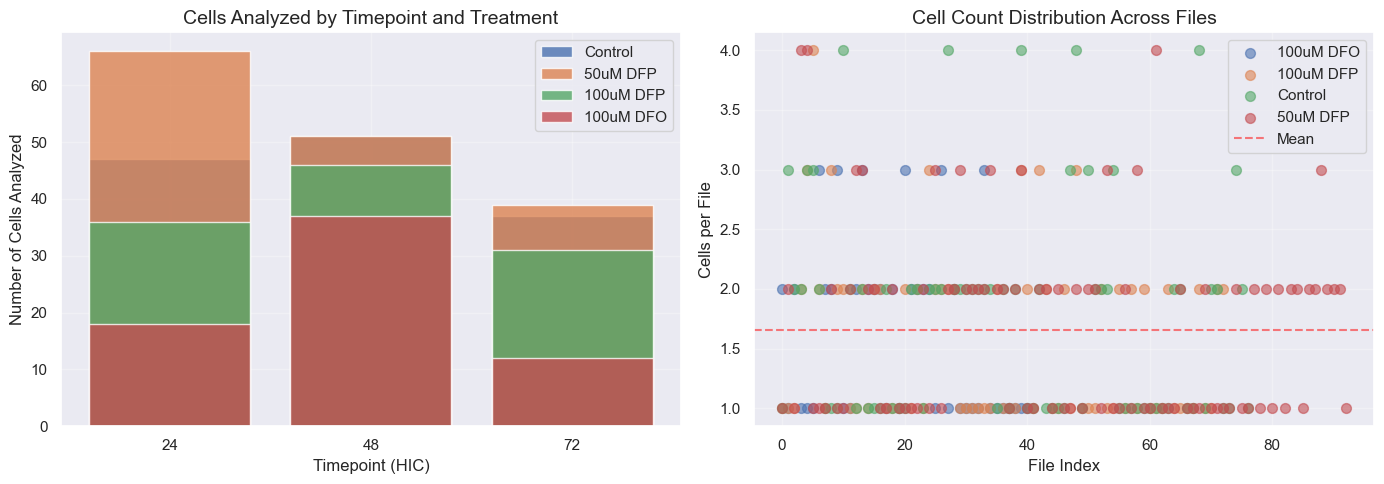


✓ Saved: Sholl_Analysis_Output\cell_count_summary.png


In [28]:
# Summary visualization: Cell counts by treatment and timepoint
if len(df_cell_summary) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Cell counts by HIC
    hic_counts = df_cell_summary.groupby(['HIC', 'treatment'], observed=True).size().reset_index(name='count')

    ax = axes[0]
    for treatment in hic_counts['treatment'].unique():
        data = hic_counts[hic_counts['treatment'] == treatment]
        ax.bar(
            data['HIC'],
            data['count'],
            label=treatment,
            alpha=0.8
        )
    ax.set_xlabel('Timepoint (HIC)', fontsize=12)
    ax.set_ylabel('Number of Cells Analyzed', fontsize=12)
    ax.set_title('Cells Analyzed by Timepoint and Treatment', fontsize=14)
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Cell counts per file
    ax = axes[1]
    file_data = df_cell_summary.groupby(['file', 'treatment'], observed=True).size().reset_index(name='count')

    for treatment in file_data['treatment'].unique():
        data = file_data[file_data['treatment'] == treatment]
        ax.scatter(
            range(len(data)),
            data['count'],
            label=treatment,
            alpha=0.6,
            s=50
        )

    ax.axhline(y=file_data['count'].mean(), color='red', linestyle='--', alpha=0.5, label='Mean')
    ax.set_xlabel('File Index', fontsize=12)
    ax.set_ylabel('Cells per File', fontsize=12)
    ax.set_title('Cell Count Distribution Across Files', fontsize=14)
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(output_dir / 'cell_count_summary.png', dpi=300, bbox_inches='tight')
    plt.show()

    print(f"\n✓ Saved: {output_dir / 'cell_count_summary.png'}")

In [29]:
# Save results
output_csv = output_dir / 'sholl_analysis_phalloidin.csv'
df_sholl.to_csv(output_csv, index=False)
print(f"Saved results to: {output_csv}")

Saved results to: Sholl_Analysis_Output\sholl_analysis_phalloidin.csv


## Sholl Analysis Plots

Replicating the Sholl plot style from `01_plotting_statistics.ipynb` with log scale and dynamic x-axis.

In [30]:
# Sholl Analysis Plot (matching 01_plotting_statistics.ipynb style)
if len(df_sholl) > 0:
    # Ensure treatment is ordered as categorical
    if not isinstance(df_sholl['treatment'].dtype, pd.CategoricalDtype):
        df_sholl['treatment'] = pd.Categorical(
            df_sholl['treatment'],
            categories=['Control', '50uM DFP', '100uM DFP', '100uM DFO'],
            ordered=True
        )

    # For each HIC group, filter to remove radii where max crossings is 0
    # This allows each facet to have its own meaningful x-axis range
    df_sholl_filtered = []
    for hic in df_sholl['HIC'].unique():
        hic_data = df_sholl[df_sholl['HIC'] == hic].copy()
        # Find the max radius where any cell has crossings > 0
        max_active_radius = hic_data[hic_data['crossings'] > 0]['radius_um'].max()
        if pd.notna(max_active_radius):
            # Keep data up to this radius
            hic_data_trimmed = hic_data[hic_data['radius_um'] <= max_active_radius]
            df_sholl_filtered.append(hic_data_trimmed)
        else:
            # Keep all data if no filtering needed
            df_sholl_filtered.append(hic_data)

    df_sholl_plot = pd.concat(df_sholl_filtered, ignore_index=True)

    # Re-apply categorical ordering after concat (concat can lose the dtype)
    df_sholl_plot['treatment'] = pd.Categorical(
        df_sholl_plot['treatment'],
        categories=['Control', '50uM DFP', '100uM DFP', '100uM DFO'],
        ordered=True
    )

    # Sort by treatment to ensure categorical order is respected in plotting
    df_sholl_plot = df_sholl_plot.sort_values('treatment')

    # Create unique cell identifier (file + morphology_id)
    # This is critical because morphology_id values repeat across different files
    df_sholl_plot['unique_cell_id'] = df_sholl_plot['file'].astype(str) + '_' + df_sholl_plot['morphology_id'].astype(str)

    # Print sample sizes per group for verification
    print("\n" + "="*60)
    print("SHOLL PLOT SAMPLE SIZES (n per group)")
    print("="*60)
    sample_sizes = df_sholl_plot.groupby(['HIC', 'treatment'], observed=True)['unique_cell_id'].nunique().reset_index()
    sample_sizes.columns = ['HIC', 'Treatment', 'n_cells']
    for hic in sorted(sample_sizes['HIC'].unique()):
        print(f"\n{hic}HIC:")
        hic_samples = sample_sizes[sample_sizes['HIC'] == hic]
        for _, row in hic_samples.iterrows():
            print(f"  {row['Treatment']}: n={row['n_cells']}")
    print("="*60 + "\n")

    # Add tiny adjustment for log scale (avoid log(0))
    df_sholl_plot['crossings_adj'] = df_sholl_plot['crossings'] + 0.00000000000000000000000000001

    # Calculate figure size based on number of HIC timepoints
    num_hics = len(df_sholl_plot['HIC'].unique())
    ncols = 2  # 2 columns per row
    nrows = int(np.ceil(num_hics / ncols))
    fig_width = 7 * ncols
    fig_height = 5 * nrows

    (
        so.Plot(df_sholl_plot, x='radius_um', y='crossings_adj', color='treatment')
        .facet('HIC', wrap=ncols)
        .add(so.Line(), so.Agg('mean'))
        .add(so.Band(alpha=0.2), so.Est(errorbar='se'))
        .scale(color='colorblind')
        .scale(y=so.Continuous(trans='log'))
        .share(x=False)  # Allow each facet to have its own x-axis range
        .label(
            x='Sholl radius (µm)',
            y='log(Sholl crossings)',
            color='Treatment'
        )
        .theme(sns.plotting_context('talk'))
        .layout(size=(fig_width, fig_height))
        .save(output_dir / 'sholl_profiles.svg', bbox_inches='tight')
        .save(output_dir / 'sholl_profiles.png', dpi=300, bbox_inches='tight')
    )

    print(f"✓ Saved: {output_dir / 'sholl_profiles.svg'}")
else:
    print("No Sholl data available for plotting")


SHOLL PLOT SAMPLE SIZES (n per group)

24HIC:
  Control: n=47
  50uM DFP: n=66
  100uM DFP: n=36
  100uM DFO: n=18

48HIC:
  Control: n=51
  50uM DFP: n=51
  100uM DFP: n=46
  100uM DFO: n=37

72HIC:
  Control: n=37
  50uM DFP: n=39
  100uM DFP: n=31
  100uM DFO: n=12

✓ Saved: Sholl_Analysis_Output\sholl_profiles.svg
✓ Saved: Sholl_Analysis_Output\sholl_profiles.svg


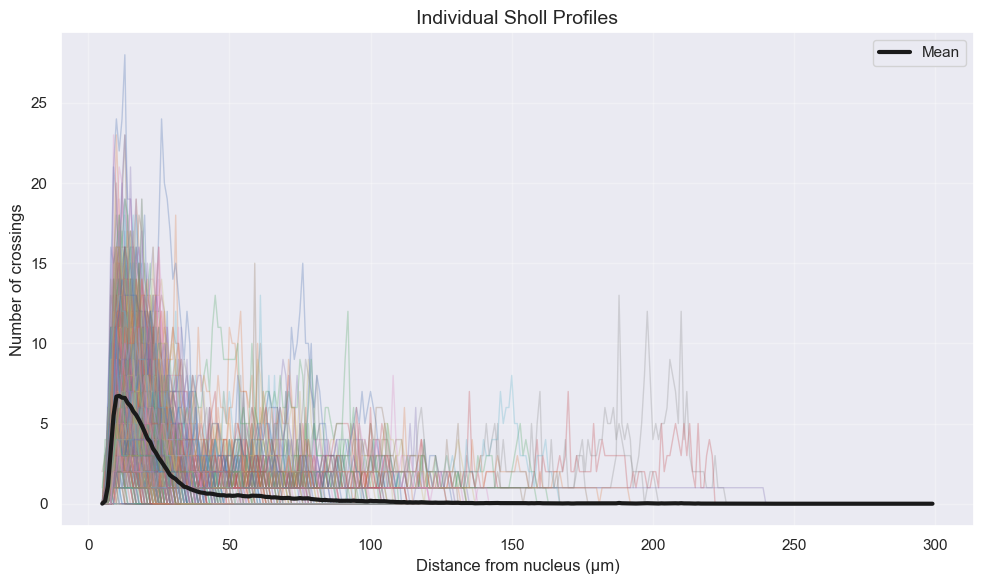

In [31]:
# Plot individual Sholl profiles
fig, ax = plt.subplots(figsize=(10, 6))

for (file, morph_id), group in df_sholl.groupby(['file', 'morphology_id']):
    ax.plot(group['radius_um'], group['crossings'], alpha=0.3, linewidth=1)

# Overlay mean
avg_profile = df_sholl.groupby('radius_um')['crossings'].mean()
ax.plot(avg_profile.index, avg_profile.values, 'k-', linewidth=3, label='Mean')

ax.set_xlabel('Distance from nucleus (µm)', fontsize=12)
ax.set_ylabel('Number of crossings', fontsize=12)
ax.set_title('Individual Sholl Profiles', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(output_dir / 'individual_sholl_profiles.png', dpi=300)
plt.show()

## Summary Statistics

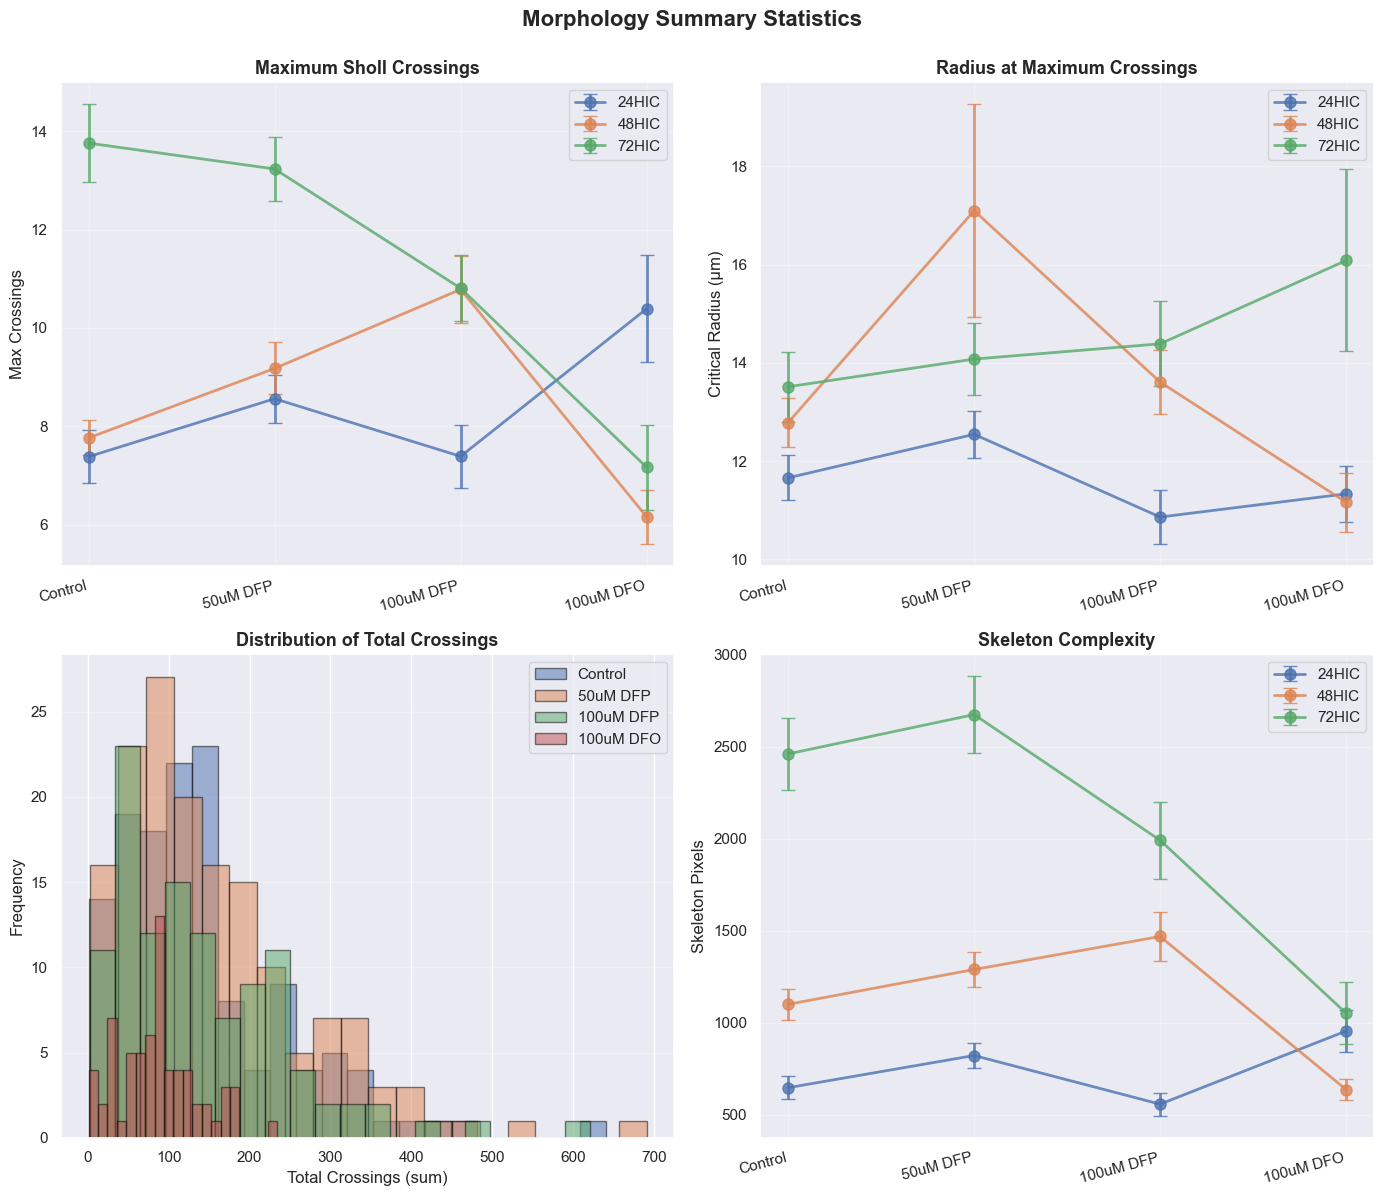

✓ Saved: Sholl_Analysis_Output\summary_statistics.png

NUMERICAL SUMMARY BY TREATMENT
              max_crossings             radius_at_max        total_crossings  \
                       mean   std count          mean    std            mean   
HIC treatment                                                                  
24  Control            7.38  3.70    47         11.66   3.13           71.51   
    50uM DFP           8.56  3.99    66         12.55   3.87           87.64   
    100uM DFP          7.39  3.80    36         10.86   3.28           59.64   
    100uM DFO         10.39  4.63    18         11.33   2.40          100.28   
48  Control            7.76  2.53    51         12.78   3.50          118.94   
    50uM DFP           9.18  3.77    51         17.10  15.44          140.16   
    100uM DFP         10.78  4.61    46         13.61   4.40          154.63   
    100uM DFO          6.16  3.36    37         11.16   3.68           71.49   
72  Control           13.76  4.78 

In [32]:
# Summary statistics and comparison plots
if len(df_cell_summary) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))

    # 1. Max crossings by treatment and HIC
    ax = axes[0, 0]
    for hic in sorted(df_cell_summary['HIC'].unique()):
        hic_data = df_cell_summary[df_cell_summary['HIC'] == hic]
        positions = np.arange(len(hic_data['treatment'].cat.categories))

        means = []
        sems = []
        for treatment in hic_data['treatment'].cat.categories:
            data = hic_data[hic_data['treatment'] == treatment]['max_crossings']
            means.append(data.mean() if len(data) > 0 else 0)
            sems.append(data.sem() if len(data) > 0 else 0)

        ax.errorbar(
            positions, means, yerr=sems,
            marker='o', linewidth=2, markersize=8,
            label=f'{hic}HIC', alpha=0.8, capsize=5
        )

    ax.set_xticks(positions)
    ax.set_xticklabels(hic_data['treatment'].cat.categories, rotation=15, ha='right')
    ax.set_ylabel('Max Crossings', fontsize=12)
    ax.set_title('Maximum Sholl Crossings', fontsize=13, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # 2. Critical radius by treatment and HIC
    ax = axes[0, 1]
    for hic in sorted(df_cell_summary['HIC'].unique()):
        hic_data = df_cell_summary[df_cell_summary['HIC'] == hic]
        positions = np.arange(len(hic_data['treatment'].cat.categories))

        means = []
        sems = []
        for treatment in hic_data['treatment'].cat.categories:
            data = hic_data[hic_data['treatment'] == treatment]['radius_at_max']
            means.append(data.mean() if len(data) > 0 else 0)
            sems.append(data.sem() if len(data) > 0 else 0)

        ax.errorbar(
            positions, means, yerr=sems,
            marker='o', linewidth=2, markersize=8,
            label=f'{hic}HIC', alpha=0.8, capsize=5
        )

    ax.set_xticks(positions)
    ax.set_xticklabels(hic_data['treatment'].cat.categories, rotation=15, ha='right')
    ax.set_ylabel('Critical Radius (µm)', fontsize=12)
    ax.set_title('Radius at Maximum Crossings', fontsize=13, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # 3. Total crossings distribution
    ax = axes[1, 0]
    for treatment in df_cell_summary['treatment'].cat.categories:
        data = df_cell_summary[df_cell_summary['treatment'] == treatment]['total_crossings']
        if len(data) > 0:
            ax.hist(data, bins=20, alpha=0.5, label=treatment, edgecolor='black')

    ax.set_xlabel('Total Crossings (sum)', fontsize=12)
    ax.set_ylabel('Frequency', fontsize=12)
    ax.set_title('Distribution of Total Crossings', fontsize=13, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')

    # 4. Skeleton complexity
    ax = axes[1, 1]
    for hic in sorted(df_cell_summary['HIC'].unique()):
        hic_data = df_cell_summary[df_cell_summary['HIC'] == hic]
        positions = np.arange(len(hic_data['treatment'].cat.categories))

        means = []
        sems = []
        for treatment in hic_data['treatment'].cat.categories:
            data = hic_data[hic_data['treatment'] == treatment]['skeleton_pixels']
            means.append(data.mean() if len(data) > 0 else 0)
            sems.append(data.sem() if len(data) > 0 else 0)

        ax.errorbar(
            positions, means, yerr=sems,
            marker='o', linewidth=2, markersize=8,
            label=f'{hic}HIC', alpha=0.8, capsize=5
        )

    ax.set_xticks(positions)
    ax.set_xticklabels(hic_data['treatment'].cat.categories, rotation=15, ha='right')
    ax.set_ylabel('Skeleton Pixels', fontsize=12)
    ax.set_title('Skeleton Complexity', fontsize=13, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.suptitle('Morphology Summary Statistics', fontsize=16, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.savefig(output_dir / 'summary_statistics.png', dpi=300, bbox_inches='tight')
    plt.show()

    print(f"✓ Saved: {output_dir / 'summary_statistics.png'}")

    # Print numerical summary
    print("\n" + "="*60)
    print("NUMERICAL SUMMARY BY TREATMENT")
    print("="*60)
    summary_table = df_cell_summary.groupby(['HIC', 'treatment'], observed=True).agg({
        'max_crossings': ['mean', 'std', 'count'],
        'radius_at_max': ['mean', 'std'],
        'total_crossings': ['mean', 'std']
    }).round(2)
    print(summary_table)

## 📋 Analysis Complete!

### Generated Outputs:

**CSV Files:**
- `sholl_profiles_per_cell.csv` - Complete Sholl data (one row per radius per cell)
- `cell_summary_statistics.csv` - Per-cell summary metrics
- `cell_counts_per_file.csv` - Cell counts by file
- `treatment_timepoint_summary.csv` - Aggregate statistics by condition
- `processing_errors.csv` - Error log (if any failures)

**Visualizations:**
- `Skeleton_Overlays/` - Individual skeleton images with Sholl shells (3 examples per file)
- `sholl_profiles_by_treatment_timepoint.png` - Mean Sholl profiles with SEM
- `cell_count_summary.png` - Cell distribution across files
- `summary_statistics.png` - Key metrics comparison

### Next Steps:

1. **Review QC images** in `Skeleton_Overlays/` to verify analysis quality
2. **Check error log** if present to identify problematic files
3. **Statistical analysis** using the CSV outputs in your preferred tool (R, Prism, etc.)
4. **Re-run with FULL_RUN = True** to process all files (set in batch processing cell)

### Parameters Used:
- **Soma exclusion buffer:** {SOMA_EXCLUSION_BUFFER} µm
- **Minimum segment length:** {MINIMUM_SEGMENT_LENGTH} µm
- **Skeleton merge distance:** {SKELETON_MERGE_DISTANCE} µm
- **Min morphology area:** {MIN_MORPH_AREA} µm²
- **Max morphology area:** {MAX_MORPH_AREA} µm²
- **Sholl ring spacing:** {SHOLL_RING_SPACING} µm
- **Sholl outer ring:** {SHOLL_OUTER_RING} µm

In [33]:
# Final summary printout
print("\n" + "🎉"*30)
print("\n" + " "*20 + "ANALYSIS COMPLETE!")
print("\n" + "🎉"*30)
print("\n📊 Results Summary:")
print(f"   • Files processed: {len(df_sholl['file'].unique()) if len(df_sholl) > 0 else 0}")
print(f"   • Total cells: {len(df_cell_summary) if len(df_cell_summary) > 0 else 0}")
print(f"   • Sholl measurements: {len(df_sholl)}")
print(f"   • Treatments: {', '.join(df_cell_summary['treatment'].unique()) if len(df_cell_summary) > 0 else 'None'}")
print(f"   • Timepoints: {', '.join([f'{h}HIC' for h in sorted(df_cell_summary['HIC'].unique())]) if len(df_cell_summary) > 0 else 'None'}")
print(f"\n💾 All outputs saved to: {output_dir.absolute()}")
print("\n✨ Ready for statistical analysis and publication!")
print("\n" + "="*90 + "\n")


🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉

                    ANALYSIS COMPLETE!

🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉🎉

📊 Results Summary:
   • Files processed: 289
   • Total cells: 480
   • Sholl measurements: 141600


TypeError: sequence item 4: expected str instance, float found